# The famous spring animation

If you attend any conference talk on physics-informed neural networks (PINNs), there is a good chance you will see a version of the following experiment: a damped mass-spring system is simulated, sparse and noisy measurements are collected over only the **first fraction of the time domain**, and two competing models are trained:

1. A **standard neural network** (data-driven only) — given the measured data and nothing else.
2. A **PINN** (physics-informed neural network) — trained to satisfy the governing ODE everywhere, with no measured data at all.

The result is striking: the standard NN fits the observed window well but diverges immediately after. The PINN, enforced by the physics, continues to track the correct decaying oscillation across the full domain it was never shown.

This notebook builds up to that result in three animations, from simple to complex:

| Animation | What it shows |
|---|---|
| **Warm-up — sin(x)** | The same NN vs PINN idea on a function you already know: $\sin(x)$. Both models see 20 noisy measurements in $[-\pi, \pi]$; evaluation extends to $[-\pi-1.5,\;\pi+1.5]$. Here the PINN also sees the data — physics acts as a regulariser that enables extrapolation. |
| **Exact spring** | The physical mass-spring system oscillating under the closed-form solution, with a live $x(t)$ trace. Pure ground truth — no neural network involved. |
| **Training comparison** | Three panels updated epoch by epoch: the standard NN prediction, the PINN prediction, and a live overplot of both training loss curves. |

## 1. The physics: damped harmonic oscillator

The governing equation is the second-order linear ordinary differential equation (ODE):

$$
\ddot{x}(t) + 2\zeta\omega_0\,\dot{x}(t) + \omega_0^2\,x(t) = 0
$$

where:
- $x(t)$ is the displacement of the mass from equilibrium.
- $\omega_0$ is the **natural frequency** (how fast the undamped spring oscillates).
- $\zeta$ is the **damping ratio** ($\zeta < 1$ → underdamped, oscillations decay; $\zeta = 1$ → critically damped; $\zeta > 1$ → overdamped).

We use $\omega_0 = 2\pi$ rad/s and $\zeta = 0.15$ (lightly damped), with initial conditions $x(0) = 1$, $\dot{x}(0) = 0$.

The closed-form solution for the underdamped case ($\zeta < 1$) is:

$$
x(t) = e^{-\zeta\omega_0 t}\left(\cos(\omega_d t) + \frac{\zeta\omega_0}{\omega_d}\sin(\omega_d t)\right)
$$

where $\omega_d = \omega_0\sqrt{1-\zeta^2}$ is the **damped natural frequency**.

Having an exact solution is crucial: it lets us verify both models rigorously and serves as the ground truth for the spring visualisation.

## 2. Imports

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.animation as animation
from IPython.display import HTML

## 3. Physical parameters and exact solution

In [2]:
# ── Physical constants ────────────────────────────────────────────────────────
OMEGA0 = 2.0 * np.pi   # natural frequency (rad/s) — one full oscillation per second
ZETA   = 0.15          # damping ratio — lightly damped so we see several oscillations
OMEGAD = OMEGA0 * np.sqrt(1.0 - ZETA**2)  # damped frequency, slightly lower than OMEGA0

# ── Time domain ───────────────────────────────────────────────────────────────
T_END  = 3.0   # simulate up to 3 seconds (~3 full oscillation cycles)
T_DATA = 1.2   # we only give the standard NN data up to 1.2 s (40% of the domain)
               # the PINN receives NO measured data at all — only the ODE and ICs

# ── Visual scale for the spring diagram ──────────────────────────────────────
X_SCALE = 0.75  # maps x(t) ∈ [-1, 1] to ±0.75 in the spring plot axes


def exact_solution(t: np.ndarray) -> np.ndarray:
    """Analytical solution of the damped harmonic oscillator.

    Derived by substituting x(t) = e^(st) into the ODE and solving the
    characteristic equation. For the underdamped case (zeta < 1) the two
    complex conjugate roots give an oscillation multiplied by an exponential
    envelope.
    """
    envelope   = np.exp(-ZETA * OMEGA0 * t)          # decaying amplitude
    oscillation = (np.cos(OMEGAD * t)                # cosine term from IC x(0)=1
                   + (ZETA * OMEGA0 / OMEGAD) * np.sin(OMEGAD * t))  # sine from IC x'(0)=0
    return envelope * oscillation


# Quick sanity check: verify the ICs are satisfied
print(f"x(0)  = {exact_solution(np.array([0.0]))[0]:.6f}  (expected 1.0)")
# Numerical first derivative at t=0 via finite difference
eps = 1e-7
xdot0 = (exact_solution(np.array([eps])) - exact_solution(np.array([0.0]))) / eps
print(f"x'(0) ≈ {xdot0[0]:.6f}  (expected 0.0)")

x(0)  = 1.000000  (expected 1.0)
x'(0) ≈ -0.000002  (expected 0.0)


## 4. Training data

We simulate a realistic scenario where a sensor measures the spring displacement at 30 randomly chosen times in $[0, T_{\text{data}}]$, with additive Gaussian noise of standard deviation 0.05. This represents ~5% noise on a unit-amplitude signal, which is noisy but not catastrophic.

Crucially, **no measurements are taken beyond $t = 1.2$ s**. The standard NN must extrapolate blindly, while the PINN uses the ODE as its guide.

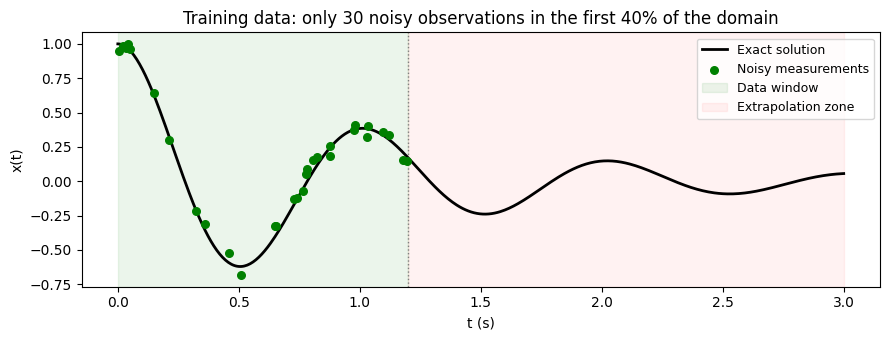

In [3]:
# ── Reproducible random data generation ──────────────────────────────────────
rng    = np.random.default_rng(seed=0)   # fixed seed for reproducibility
N_DATA = 30                              # number of sensor readings
NOISE  = 0.05                            # standard deviation of measurement noise

# Sample times uniformly in [0, T_DATA], then sort for clean plotting
t_data_np = np.sort(rng.uniform(0.0, T_DATA, N_DATA))

# Evaluate exact solution and corrupt with noise
x_data_np = exact_solution(t_data_np) + NOISE * rng.standard_normal(N_DATA)

# Convert to PyTorch tensors; shape (N, 1) so the MLP can process the batch
t_data = torch.tensor(t_data_np, dtype=torch.float32).reshape(-1, 1)
x_data = torch.tensor(x_data_np, dtype=torch.float32).reshape(-1, 1)

# ── Quick visualisation of the data ──────────────────────────────────────────
t_fine = np.linspace(0, T_END, 500)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(t_fine, exact_solution(t_fine), 'k-', lw=2, label='Exact solution')
ax.scatter(t_data_np, x_data_np, s=30, c='green', zorder=5, label='Noisy measurements')
ax.axvspan(0, T_DATA, alpha=0.08, color='green', label='Data window')
ax.axvspan(T_DATA, T_END, alpha=0.05, color='red', label='Extrapolation zone')
ax.axvline(T_DATA, color='gray', lw=1, ls=':')
ax.set_xlabel('t (s)'); ax.set_ylabel('x(t)')
ax.set_title('Training data: only 30 noisy observations in the first 40% of the domain')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. Network architecture

All models in this notebook — the sin(x) warm-up and both spring models — use **the same MLP architecture**: three hidden layers of width 64 with `tanh` activations.

Keeping the architecture identical across all four models isolates the effect of the training objective. The only differences are *what each model is trained on* and *which loss terms are included*.

Why `tanh`?
- It is smooth (infinitely differentiable), which is essential for the PINN: we compute second derivatives via two applications of `torch.autograd.grad`, so the network needs well-defined second derivatives.
- Rectified Linear Unit (ReLU) has zero second derivative almost everywhere, making it a poor choice for second-order ODEs/PDEs.

In [4]:
class MLP(nn.Module):
    """Simple feed-forward network: scalar t → scalar x.

    Both the standard NN and the PINN use this same architecture.
    The difference is entirely in how the loss function is constructed.
    """

    def __init__(self, width: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, width),      # input layer: scalar t
            nn.Tanh(),                # smooth activation — required for autograd derivatives
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1),      # output layer: scalar x(t)
        )

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        return self.net(t)

## 5b. Warm-up: approximating sin(x)

Before tackling the spring we demonstrate the core PINN advantage — **extrapolation** — on a function you already know.

**Setup**: 20 noisy measurements of $\sin(x)$ are taken inside the training window $[-\pi, \pi]$. Both models are then evaluated on the wider range $[-\pi - 1.5,\; \pi + 1.5]$.

| Model | Loss function |
|---|---|
| **Standard NN** | Data mean squared error (MSE) only — fits the 20 noisy points |
| **PINN** | Data MSE + ODE residual: enforces $u'' + u = 0$ (the equation $\sin(x)$ satisfies), weighted by $\lambda = 20$ |

Inside the training window both models fit the data well. Outside it, the standard NN extrapolates randomly; the PINN continues to follow $\sin(x)$, guided by the ODE constraint.

Key difference from the spring experiment: **the sin(x) PINN also sees the data**. Physics here acts as a regulariser that prevents the model from overfitting and enables extrapolation. The spring PINN takes this further — it receives *no data at all*.

In [ ]:
# ── Data ─────────────────────────────────────────────────────────────────────
rng_sin  = np.random.default_rng(seed=42)
N_SIN    = 20
x_sin_np = np.linspace(-np.pi, np.pi, N_SIN)
y_sin_np = np.sin(x_sin_np) + 0.1 * rng_sin.standard_normal(N_SIN)
x_sin_t  = torch.tensor(x_sin_np.reshape(-1, 1), dtype=torch.float32)
y_sin_t  = torch.tensor(y_sin_np.reshape(-1, 1), dtype=torch.float32)

# Collocation points — requires_grad so autograd can differentiate through the network
x_col_sin = torch.linspace(-np.pi, np.pi, 300).reshape(-1, 1).requires_grad_(True)

# Evaluation grid extending 1.5 rad beyond the training window on both sides
X_SIN_LO, X_SIN_HI = -np.pi - 1.5, np.pi + 1.5
x_eval_sin_np = np.linspace(X_SIN_LO, X_SIN_HI, 500)
x_eval_sin_t  = torch.tensor(x_eval_sin_np.reshape(-1, 1), dtype=torch.float32)
y_exact_sin   = np.sin(x_eval_sin_np)

# ── Hyperparameters ───────────────────────────────────────────────────────────
N_SIN_EPOCHS   = 5000
SIN_SAVE_EVERY = 50
PHY_WEIGHT_SIN = 20.0

# ── Models (same MLP used for the spring) ────────────────────────────────────
torch.manual_seed(10)
nn_sin_model   = MLP()
opt_nn_sin     = torch.optim.Adam(nn_sin_model.parameters(), lr=0.01)

torch.manual_seed(11)
pinn_sin_model = MLP()
opt_pinn_sin   = torch.optim.Adam(pinn_sin_model.parameters(), lr=0.01)

# ── Snapshot storage ──────────────────────────────────────────────────────────
n_sin_snaps     = N_SIN_EPOCHS // SIN_SAVE_EVERY + 1
nn_sin_snaps    = np.empty((n_sin_snaps, len(x_eval_sin_np)), dtype=np.float32)
pinn_sin_snaps  = np.empty((n_sin_snaps, len(x_eval_sin_np)), dtype=np.float32)
nn_sin_losses   = []
pinn_sin_losses = []
sin_epoch_list  = []
sin_snap_idx    = 0

# ── Training loop ─────────────────────────────────────────────────────────────
print("Training sin(x) models…")
for epoch in range(N_SIN_EPOCHS + 1):

    # Standard NN — data MSE only
    opt_nn_sin.zero_grad()
    l_nn_sin = torch.mean((nn_sin_model(x_sin_t) - y_sin_t) ** 2)
    l_nn_sin.backward()
    opt_nn_sin.step()

    # PINN — data MSE + ODE residual (u'' + u = 0)
    opt_pinn_sin.zero_grad()
    l_data_sin = torch.mean((pinn_sin_model(x_sin_t) - y_sin_t) ** 2)

    u    = pinn_sin_model(x_col_sin)
    u_x  = torch.autograd.grad(u,   x_col_sin, torch.ones_like(u),   create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_col_sin, torch.ones_like(u_x), create_graph=True)[0]
    l_phy_sin  = torch.mean((u_xx + u) ** 2)
    l_pinn_sin = l_data_sin + PHY_WEIGHT_SIN * l_phy_sin
    l_pinn_sin.backward()
    opt_pinn_sin.step()

    if epoch % SIN_SAVE_EVERY == 0:
        with torch.no_grad():
            nn_sin_snaps[sin_snap_idx]   = nn_sin_model(x_eval_sin_t).numpy().flatten()
            pinn_sin_snaps[sin_snap_idx] = pinn_sin_model(x_eval_sin_t).numpy().flatten()
        nn_sin_losses.append(l_nn_sin.item())
        pinn_sin_losses.append(l_pinn_sin.item())
        sin_epoch_list.append(epoch)
        sin_snap_idx += 1

nn_sin_snaps   = nn_sin_snaps[:sin_snap_idx]
pinn_sin_snaps = pinn_sin_snaps[:sin_snap_idx]
print(f"Done.  {sin_snap_idx} snapshots saved.")

In [ ]:
X_TRAIN_LO_SIN, X_TRAIN_HI_SIN = -np.pi, np.pi
Y_SIN_LIM = (-2.5, 2.5)

fig_sin, (ax_sn, ax_sp, ax_sl) = plt.subplots(
    1, 3, figsize=(18, 5.0),
    gridspec_kw={"width_ratios": [1.4, 1.4, 1.2]},
)
fig_sin.subplots_adjust(wspace=0.35, left=0.06, right=0.97, top=0.87, bottom=0.12)

# ── Prediction panels ─────────────────────────────────────────────────────────
for ax, title, col in (
    (ax_sn, "Standard NN  (data only)",        "tomato"),
    (ax_sp, r"PINN  (data + $u''+u=0$)",        "royalblue"),
):
    ax.fill_betweenx(Y_SIN_LIM, X_TRAIN_LO_SIN, X_TRAIN_HI_SIN,
                     color="green", alpha=0.07, label="training window")
    ax.axvline(X_TRAIN_LO_SIN, color="gray", lw=1.0, ls=":", alpha=0.8)
    ax.axvline(X_TRAIN_HI_SIN, color="gray", lw=1.0, ls=":", alpha=0.8)
    ax.plot(x_eval_sin_np, y_exact_sin, "k-", lw=1.6, label=r"Exact $\sin(x)$", zorder=3)
    ax.set_xlim(X_SIN_LO, X_SIN_HI)
    ax.set_ylim(*Y_SIN_LIM)
    ax.set_xlabel("x", fontsize=11)
    ax.set_ylabel("u(x)", fontsize=11)
    ax.set_title(title, fontsize=11, color=col, fontweight="bold", pad=8)
    ax.grid(alpha=0.25)

ax_sn.scatter(x_sin_np, y_sin_np, s=20, c="green", zorder=5,
              label="Training data (20 noisy pts)")
ax_sn.legend(fontsize=8, loc="upper right")
ax_sp.legend(fontsize=8, loc="upper right")

line_nn_sin,   = ax_sn.plot([], [], color="tomato",    lw=2.0, ls="--")
line_pinn_sin, = ax_sp.plot([], [], color="royalblue", lw=2.0, ls="-")
txt_nn_sin   = ax_sn.text(0.03, 0.07, "", transform=ax_sn.transAxes,
                           fontsize=9, color="darkred",  family="monospace")
txt_pinn_sin = ax_sp.text(0.03, 0.07, "", transform=ax_sp.transAxes,
                           fontsize=9, color="darkblue", family="monospace")

# ── Loss panel ────────────────────────────────────────────────────────────────
sin_loss_min = min(min(nn_sin_losses), min(pinn_sin_losses)) * 0.3
sin_loss_max = max(nn_sin_losses[0], pinn_sin_losses[0]) * 5.0
ax_sl.set_xlim(0, N_SIN_EPOCHS)
ax_sl.set_ylim(sin_loss_min, sin_loss_max)
ax_sl.set_yscale("log")
ax_sl.set_xlabel("Epoch", fontsize=11)
ax_sl.set_ylabel("Loss  (log scale)", fontsize=11)
ax_sl.set_title("Training loss", fontsize=11, fontweight="bold", pad=8)
ax_sl.grid(alpha=0.3, which="both")
ax_sl.plot(sin_epoch_list, nn_sin_losses,   color="tomato",    lw=1.2, alpha=0.20, ls="--")
ax_sl.plot(sin_epoch_list, pinn_sin_losses, color="royalblue", lw=1.2, alpha=0.20, ls="-")
loss_line_nn_sin,   = ax_sl.plot([], [], color="tomato",    lw=2.2, ls="--", label="NN loss")
loss_line_pinn_sin, = ax_sl.plot([], [], color="royalblue", lw=2.2, ls="-",  label="PINN loss")
ax_sl.legend(fontsize=9, loc="upper right")

epoch_title_sin = fig_sin.text(0.5, 0.945, "", ha="center", fontsize=11, fontweight="bold")


def _update_sin(i: int):
    ep = sin_epoch_list[i]
    line_nn_sin.set_data(x_eval_sin_np, nn_sin_snaps[i])
    txt_nn_sin.set_text(f"epoch {ep:5d}   loss {nn_sin_losses[i]:.2e}")
    line_pinn_sin.set_data(x_eval_sin_np, pinn_sin_snaps[i])
    txt_pinn_sin.set_text(f"epoch {ep:5d}   loss {pinn_sin_losses[i]:.2e}")
    loss_line_nn_sin.set_data(sin_epoch_list[:i + 1],   nn_sin_losses[:i + 1])
    loss_line_pinn_sin.set_data(sin_epoch_list[:i + 1], pinn_sin_losses[:i + 1])
    epoch_title_sin.set_text(f"Training epoch: {ep} / {N_SIN_EPOCHS}")
    return (line_nn_sin, line_pinn_sin, txt_nn_sin, txt_pinn_sin,
            loss_line_nn_sin, loss_line_pinn_sin, epoch_title_sin)


ani_sin = animation.FuncAnimation(
    fig_sin, _update_sin,
    frames=len(sin_epoch_list),
    interval=90,
    blit=False,
)
plt.close(fig_sin)
print(f"sin(x) animation ready: {len(sin_epoch_list)} frames  ({90 * len(sin_epoch_list) / 1000:.1f} s playback).")

## 6. The damped spring training loop

With the sin(x) warm-up done, we now train the spring models. Both are trained **simultaneously**, one gradient step each per epoch. At fixed intervals we save a snapshot of each model's prediction over the full evaluation grid — these snapshots become the animation frames.

### Standard NN loss
Pure mean squared error (MSE) against the 30 noisy measurements:
$$\mathcal{L}_{\text{NN}} = \frac{1}{N}\sum_{i=1}^{N}(\hat{x}(t_i) - x_i^{\text{obs}})^2$$

### PINN loss
Three components — ODE residual, position initial condition (IC), velocity IC:
$$\mathcal{L}_{\text{PINN}} = \underbrace{\frac{1}{N_f}\sum_j r(t_j)^2}_{\text{ODE residual}} + \lambda\underbrace{(\hat{x}(0)-1)^2}_{\text{position IC}} + \lambda\underbrace{(\hat{x}'(0)-0)^2}_{\text{velocity IC}}$$

where $r(t) = \ddot{\hat{x}} + 2\zeta\omega_0\dot{\hat{x}} + \omega_0^2\hat{x}$ and $\lambda = 10$.

The collocation points $\{t_j\}$ are sampled uniformly over the **full** domain $[0, T_{\text{end}}]$ — this is what gives the PINN global knowledge of the physics. Unlike the sin(x) case, the **spring PINN receives no measured data at all**.

In [5]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
N_EPOCHS    = 5000   # total training epochs (both models trained for the same number)
SAVE_EVERY  = 50     # save a prediction snapshot every 50 epochs → 101 animation frames
N_COL       = 1500   # number of PINN collocation points (where ODE residual is evaluated)
IC_WEIGHT   = 10.0   # lambda: upweights IC losses so they are not swamped by the ODE term

# ── Initialise both models and optimisers ────────────────────────────────────
torch.manual_seed(1)   # fixed seed ensures the NN starts from the same weights each run
nn_model = MLP()
nn_opt   = torch.optim.Adam(nn_model.parameters(), lr=1e-3)

torch.manual_seed(2)   # different seed for the PINN so they start independently
pinn_model = MLP()
pinn_opt   = torch.optim.Adam(pinn_model.parameters(), lr=1e-3)

# ── PINN-specific tensors (created once, reused every epoch) ─────────────────
# Collocation points need requires_grad=True so autograd can differentiate
# the network output with respect to the input time.
t_col = (T_END * torch.rand(N_COL, 1)).requires_grad_(True)

# IC tensors: fixed single points at t=0
t0 = torch.zeros(1, 1)   # the time at which we check the initial conditions

# ── Evaluation grid (used to record animation snapshots) ─────────────────────
t_eval_np = np.linspace(0.0, T_END, 400)   # 400 points across the full domain
t_eval    = torch.tensor(t_eval_np, dtype=torch.float32).reshape(-1, 1)
x_exact_eval = exact_solution(t_eval_np)   # ground truth on the same grid

# ── Storage for animation snapshots ──────────────────────────────────────────
n_snaps    = N_EPOCHS // SAVE_EVERY + 1
nn_snaps   = np.empty((n_snaps, len(t_eval_np)), dtype=np.float32)   # NN predictions
pinn_snaps = np.empty((n_snaps, len(t_eval_np)), dtype=np.float32)   # PINN predictions
nn_losses  = []    # NN loss at each snapshot epoch
pinn_losses = []   # PINN loss at each snapshot epoch
epoch_list  = []   # epoch indices corresponding to each snapshot
snap_idx    = 0    # current write position in the snapshot arrays

# ── Joint training loop ───────────────────────────────────────────────────────
print("Training… (≈30 s on CPU)")
for epoch in range(N_EPOCHS + 1):

    # ── Standard NN step ──────────────────────────────────────────────────────
    nn_opt.zero_grad()
    # Loss is MSE between prediction and the 30 noisy observations
    l_nn = torch.mean((nn_model(t_data) - x_data) ** 2)
    l_nn.backward()
    nn_opt.step()

    # ── PINN step ─────────────────────────────────────────────────────────────
    pinn_opt.zero_grad()

    # Forward pass at collocation points
    x_c = pinn_model(t_col)   # shape (N_COL, 1)

    # First derivative dx/dt via autograd.
    # create_graph=True keeps the graph so we can differentiate again for ddx.
    dx = torch.autograd.grad(
        x_c, t_col,
        grad_outputs=torch.ones_like(x_c),
        create_graph=True,
    )[0]

    # Second derivative d²x/dt² — requires the graph from the first grad call
    ddx = torch.autograd.grad(
        dx, t_col,
        grad_outputs=torch.ones_like(dx),
        create_graph=True,
    )[0]

    # ODE residual: if the network is a perfect solution, residual = 0 everywhere
    residual = ddx + 2.0 * ZETA * OMEGA0 * dx + OMEGA0**2 * x_c
    l_ode    = torch.mean(residual ** 2)   # penalise any departure from zero

    # IC loss 1: x(0) = 1  (position initial condition)
    l_x0 = (pinn_model(t0) - 1.0) ** 2

    # IC loss 2: x'(0) = 0  (velocity initial condition)
    # We need a fresh graph through t0 to differentiate with respect to it
    t0g  = t0.clone().requires_grad_(True)
    dx0  = torch.autograd.grad(
        pinn_model(t0g), t0g,
        grad_outputs=torch.ones(1, 1),
        create_graph=True,
    )[0]
    l_v0 = dx0 ** 2   # penalise any nonzero initial velocity

    # Total PINN loss — IC terms weighted by IC_WEIGHT to prevent them being
    # overwhelmed by the large ODE residual from 1500 collocation points
    l_pinn = l_ode + IC_WEIGHT * (l_x0 + l_v0).mean()
    l_pinn.backward()
    pinn_opt.step()

    # ── Save snapshot every SAVE_EVERY epochs ─────────────────────────────────
    if epoch % SAVE_EVERY == 0:
        with torch.no_grad():   # disable grad tracking — we only need forward passes here
            nn_snaps[snap_idx]   = nn_model(t_eval).numpy().flatten()
            pinn_snaps[snap_idx] = pinn_model(t_eval).numpy().flatten()
        nn_losses.append(l_nn.item())
        pinn_losses.append(l_pinn.item())
        epoch_list.append(epoch)
        snap_idx += 1

# Trim arrays to actual number of snapshots saved
nn_snaps   = nn_snaps[:snap_idx]
pinn_snaps = pinn_snaps[:snap_idx]
print(f"Done. {snap_idx} snapshots saved (one animation frame each).")

Training… (≈30 s on CPU)
Done. 101 snapshots saved (one animation frame each).


## 7. Spring geometry helper

To draw a coil spring we generate a zigzag line between two anchor points. The coils alternate left and right by a fixed width $w$, with small straight segments at each end connecting cleanly to the wall and the mass block.

In [6]:
def spring_xy(
    y_top:    float,   # y-coordinate of the fixed support (ceiling)
    y_bottom: float,   # y-coordinate of the top of the mass block
    n_coils:  int   = 7,     # number of full zigzag coils
    w:        float = 0.25,  # half-width of each coil
) -> tuple:
    """Return (x_pts, y_pts) that trace a vertical zigzag coil spring.

    Layout (y axis points upward):
        y_top ─── short straight segment ──► first coil left/right ──► ... ──► y_bottom
    """
    margin   = 0.06                      # length of the straight end segments
    y_coil_t = y_top    - margin         # where the zigzag coils begin
    y_coil_b = y_bottom + margin         # where the zigzag coils end

    n_pts  = n_coils * 2                 # two vertices per coil (left + right)
    y_coil = np.linspace(y_coil_t, y_coil_b, n_pts)  # evenly spaced y-positions

    # Alternate x-position: +w for even indices, -w for odd → zigzag
    x_coil = np.array([w * (1.0 if i % 2 == 0 else -1.0) for i in range(n_pts)])

    # Prepend the top anchor (0, y_top) and append the bottom anchor (0, y_bottom)
    x = np.concatenate([[0.0], x_coil, [0.0]])
    y = np.concatenate([[y_top], y_coil, [y_bottom]])
    return x, y

## 8. Animation 1: exact damped spring

The first animation isolates the physical system itself. The mass sweeps through three full oscillation cycles ($t = 0 \to 3$ s) while the amplitude envelope $e^{-\zeta\omega_0 t}$ damps it toward rest. No neural networks are involved — this is pure ground truth derived from the closed-form solution.

`ani_spring` runs on its own 120-frame grid, independent of the training snapshots.

In [ ]:
# ── Spring diagram constants (reused by Animation 2) ─────────────────────────
Y_WALL = 1.25   # ceiling y-position
Y_EQ   = 0.0    # equilibrium
MASS_W = 0.34   # mass block width  (visual units)
MASS_H = 0.17   # mass block height

# ── Frame grid: 120 frames sweeping t = 0 → T_END ───────────────────────────
N_SPRING_FRAMES = 120
t_spring_solo = np.linspace(0.0, T_END, N_SPRING_FRAMES)
x_spring_solo = exact_solution(t_spring_solo)

# ── Figure: two panels ────────────────────────────────────────────────────────
fig_s, (ax_s, ax_xt) = plt.subplots(
    1, 2,
    figsize=(9.5, 6.0),
    gridspec_kw={"width_ratios": [1, 1.6]},
)
fig_s.subplots_adjust(left=0.05, right=0.97, top=0.88, bottom=0.10, wspace=0.30)
fig_s.suptitle(
    r"Exact damped spring  —  $\omega_0 = 2\pi$ rad/s,  $\zeta = 0.15$",
    fontsize=12, fontweight="bold",
)

# ── Left panel: spring diagram ────────────────────────────────────────────────
ax_s.set_xlim(-0.75, 0.75)
ax_s.set_ylim(-1.45, 1.55)
ax_s.set_aspect("equal")
ax_s.axis("off")

# Ceiling hatch
ax_s.plot([-0.6, 0.6], [Y_WALL, Y_WALL], "k-", lw=3)
for xi in np.linspace(-0.55, 0.55, 10):
    ax_s.plot([xi, xi - 0.07], [Y_WALL, Y_WALL + 0.10], "k-", lw=1.2)

# Equilibrium guide
ax_s.axhline(Y_EQ, color="gray", lw=0.7, ls="--", alpha=0.5)
ax_s.text(0.42, Y_EQ + 0.04, "eq.", fontsize=8, color="gray", alpha=0.7)

# Dynamic spring elements
spring_line_s, = ax_s.plot([], [], "k-", lw=2)
mass_patch_s = mpatches.Rectangle(
    (-MASS_W / 2, -MASS_H / 2), MASS_W, MASS_H,
    facecolor="steelblue", edgecolor="k", lw=1.5,
)
ax_s.add_patch(mass_patch_s)
spring_info_s = ax_s.text(0, -1.28, "", ha="center", fontsize=9.5, color="#222222")

# ── Right panel: x(t) graph ───────────────────────────────────────────────────
t_fine_s = np.linspace(0.0, T_END, 500)
ax_xt.plot(t_fine_s, exact_solution(t_fine_s), color="steelblue", lw=1.8,
           alpha=0.25, label="x(t)")   # faint full curve as guide
ax_xt.axhline(0, color="gray", lw=0.7, ls="--", alpha=0.5)
ax_xt.set_xlim(0.0, T_END)
ax_xt.set_ylim(-1.35, 1.35)
ax_xt.set_xlabel("t  (s)", fontsize=11)
ax_xt.set_ylabel("x(t)", fontsize=11)
ax_xt.set_title("Displacement vs time", fontsize=10, pad=6)
ax_xt.grid(alpha=0.25)

# Solid trace that grows as the animation plays
trace_line, = ax_xt.plot([], [], color="steelblue", lw=2.0)
# Moving dot marking the current position
current_dot, = ax_xt.plot([], [], "o", color="tomato", ms=8, zorder=5)


# ── Update function ───────────────────────────────────────────────────────────
def _update_spring(i: int):
    t_s = t_spring_solo[i]
    x_s = x_spring_solo[i]
    y_m = Y_EQ + x_s * X_SCALE

    # Spring diagram
    sx, sy = spring_xy(Y_WALL, y_m)
    spring_line_s.set_data(sx, sy)
    mass_patch_s.set_xy((-MASS_W / 2, y_m - MASS_H / 2))
    spring_info_s.set_text(f"t = {t_s:.2f} s\nx = {x_s:+.3f}")

    # x(t) trace
    trace_line.set_data(t_spring_solo[:i + 1], x_spring_solo[:i + 1])
    current_dot.set_data([t_s], [x_s])

    return spring_line_s, mass_patch_s, spring_info_s, trace_line, current_dot


ani_spring = animation.FuncAnimation(
    fig_s, _update_spring,
    frames=N_SPRING_FRAMES,
    interval=80,   # ≈ 12.5 fps
    blit=False,
)
plt.close(fig_s)
print(f"Animation 1 ready: {N_SPRING_FRAMES} frames  ({80 * N_SPRING_FRAMES / 1000:.1f} s playback).")

## 9. Animation 2: training comparison with loss curves

Three panels, all advancing epoch by epoch through the same training snapshots:

| Panel | What it shows |
|---|---|
| **Left — Standard NN** | Prediction curve $\hat{x}(t)$ over $[0, T_\text{end}]$, updated each frame. Trained on 30 noisy points in $[0, 1.2]$ s. |
| **Centre — PINN** | Prediction curve, updated each frame. Trained on the ODE residual alone — no measured data. |
| **Right — Loss overplot** | Both NN and PINN losses on a semi-log scale. Faint full-range guide curves are drawn from the start so you can see where training is heading; the solid lines are progressively revealed as frames advance. |

In [ ]:
Y_LIM = (-1.55, 1.55)

fig_t, (ax_n, ax_p, ax_l) = plt.subplots(
    1, 3,
    figsize=(18, 5.2),
    gridspec_kw={"width_ratios": [1.4, 1.4, 1.2]},
)
fig_t.subplots_adjust(wspace=0.35, left=0.06, right=0.97, top=0.88, bottom=0.12)

# ── Static decorations: prediction panels ────────────────────────────────────
for ax, title, col in (
    (ax_n, "Standard NN  (data only)",  "tomato"),
    (ax_p, "PINN  (physics-informed)",  "royalblue"),
):
    ax.fill_betweenx(Y_LIM, 0.0,    T_DATA, color="green", alpha=0.07, label="training window")
    ax.fill_betweenx(Y_LIM, T_DATA, T_END,  color="red",   alpha=0.05, label="extrapolation zone")
    ax.axvline(T_DATA, color="gray", lw=1.0, ls=":", alpha=0.8)
    ax.plot(t_eval_np, x_exact_eval, "k-", lw=1.6, label="Exact", zorder=3)
    ax.set_xlim(0.0, T_END)
    ax.set_ylim(*Y_LIM)
    ax.set_xlabel("t  (s)", fontsize=11)
    ax.set_ylabel("x(t)", fontsize=11)
    ax.set_title(title, fontsize=11, color=col, fontweight="bold", pad=8)

ax_n.scatter(t_data_np, x_data_np, s=20, c="green", zorder=5, label="Training data")
ax_n.legend(fontsize=8, loc="upper right")
ax_p.legend(fontsize=8, loc="upper right")

line_nn,   = ax_n.plot([], [], color="tomato",    lw=2.0, ls="--")
line_pinn, = ax_p.plot([], [], color="royalblue", lw=2.0, ls="-")

txt_nn   = ax_n.text(0.03, 0.07, "", transform=ax_n.transAxes,
                     fontsize=9, color="darkred",  family="monospace")
txt_pinn = ax_p.text(0.03, 0.07, "", transform=ax_p.transAxes,
                     fontsize=9, color="darkblue", family="monospace")

# ── Static decorations: loss panel ───────────────────────────────────────────
loss_min = min(min(nn_losses), min(pinn_losses)) * 0.3
loss_max = max(nn_losses[0], pinn_losses[0]) * 5.0
ax_l.set_xlim(0, N_EPOCHS)
ax_l.set_ylim(loss_min, loss_max)
ax_l.set_yscale("log")
ax_l.set_xlabel("Epoch", fontsize=11)
ax_l.set_ylabel("Loss  (log scale)", fontsize=11)
ax_l.set_title("Training loss", fontsize=11, fontweight="bold", pad=8)
ax_l.grid(alpha=0.3, which="both")

# Faint full-range guide curves — visible from frame 0 so the viewer can
# see the entire loss trajectory and judge where current training sits
ax_l.plot(epoch_list, nn_losses,   color="tomato",    lw=1.2, alpha=0.20, ls="--")
ax_l.plot(epoch_list, pinn_losses, color="royalblue", lw=1.2, alpha=0.20, ls="-")

# Dynamic progressive-reveal lines
loss_line_nn,   = ax_l.plot([], [], color="tomato",    lw=2.2, ls="--", label="NN loss")
loss_line_pinn, = ax_l.plot([], [], color="royalblue", lw=2.2, ls="-",  label="PINN loss")
ax_l.legend(fontsize=9, loc="upper right")

epoch_title_t = fig_t.text(
    0.5, 0.945, "", ha="center", fontsize=12, fontweight="bold"
)


# ── Update function ───────────────────────────────────────────────────────────
def _update_training(i: int):
    ep = epoch_list[i]

    # NN prediction panel
    line_nn.set_data(t_eval_np, nn_snaps[i])
    txt_nn.set_text(f"epoch {ep:5d}   loss {nn_losses[i]:.2e}")

    # PINN prediction panel
    line_pinn.set_data(t_eval_np, pinn_snaps[i])
    txt_pinn.set_text(f"epoch {ep:5d}   loss {pinn_losses[i]:.2e}")

    # Loss panel: reveal history up to current frame
    loss_line_nn.set_data(epoch_list[:i + 1],   nn_losses[:i + 1])
    loss_line_pinn.set_data(epoch_list[:i + 1], pinn_losses[:i + 1])

    epoch_title_t.set_text(f"Training epoch: {ep} / {N_EPOCHS}")

    return (line_nn, line_pinn, txt_nn, txt_pinn,
            loss_line_nn, loss_line_pinn, epoch_title_t)


ani_training = animation.FuncAnimation(
    fig_t, _update_training,
    frames=len(epoch_list),
    interval=90,
    blit=False,
)
plt.close(fig_t)
print(f"Animation 2 ready: {len(epoch_list)} frames  ({90 * len(epoch_list) / 1000:.1f} s playback).")

## 10. Display all animations

### Warm-up — sin(x)

In [ ]:
HTML(ani_sin.to_jshtml())

### Exact spring — ground truth

In [ ]:
HTML(ani_spring.to_jshtml())

### Training comparison — damped spring NN vs PINN

**Why is the PINN loss so much higher than the NN loss right from epoch 0?**

This is the most common source of confusion when watching this animation, and the answer is purely about what the two loss functions are measuring:

| | Standard NN loss | PINN loss |
|---|---|---|
| **Formula** | $\frac{1}{30}\sum(\hat{x}(t_i) - x_i)^2$ | $\frac{1}{1500}\sum r(t_j)^2 + 10\,(\hat{x}(0)-1)^2 + 10\,(\hat{x}'(0))^2$ |
| **Targets** | Noisy measurements, $O(1)$ | ODE residual $r = \ddot{\hat{x}} + 2\zeta\omega_0\dot{\hat{x}} + \omega_0^2\hat{x}$ |
| **Scale at init** | MSE against $O(1)$ targets → small | $\omega_0^2 = 4\pi^2 \approx 39.5$ multiplies the displacement term → large |

Three factors combine to make the PINN loss start large:

1. **The coefficient $\omega_0^2 \approx 40$ in the ODE.** The residual is $\ddot{\hat{x}} + 2\zeta\omega_0\dot{\hat{x}} + \omega_0^2\hat{x}$. Even when the network outputs are of order 1, the $\omega_0^2 x$ term contributes residuals of order 40. The NN's loss only involves outputs versus $O(1)$ targets, so it has no such amplification.

2. **Second derivatives at a random initialisation are not small.** The $\ddot{\hat{x}}$ term requires differentiating through the full network twice. For a randomly initialised MLP with `tanh` activations, these second derivatives are non-trivial and noisy, adding further to the residual.

3. **IC penalties with weight $\lambda = 10$.** On top of the ODE term, the PINN pays $10 \times (\hat{x}(0) - 1)^2$ and $10 \times (\hat{x}'(0))^2$. At initialisation, $\hat{x}(0) \approx 0$ (random weights → near-zero output), so the position IC alone adds $\approx 10 \times 1 = 10$ to the loss.

The PINN loss is not "worse" — it is measuring a fundamentally harder objective on a different scale. As training progresses, both losses should fall; the PINN's slower descent reflects the difficulty of satisfying an ODE at 1500 points, not a failure to learn.

---

**What to observe as the animation plays:**

- **Early epochs (0–500)**: both prediction curves are nearly random. The loss gap is largest at epoch 0, exactly for the reasons above.
- **Mid training (500–2000)**: the standard NN rapidly fits the training window (green region); its prediction beyond $t = 1.2$ s remains wrong or diverges. The NN loss drops steeply while the PINN loss decreases more slowly.
- **Late training (2000–5000)**: the PINN converges on the correct decaying oscillation across the full domain, pulled there by the ODE residual even where no data exists. The NN loss has flattened (it has memorised the 30 points); the PINN loss continues declining.
- **The PINN loss stays above the NN loss for the entire run.** This is expected for all the reasons above. The right measure of quality is extrapolation accuracy, not the loss number itself.
- Compare with the sin(x) animation: there the PINN also sees the data and the ODE is $u''+u=0$ (coefficients all of order 1), so both losses start on a much more similar scale. The spring's $\omega_0^2 \approx 40$ is the main driver of the large initial gap here.
- The faint background curves in the loss panel show the complete trajectory — use them to judge how far each model still has to go.

In [ ]:
HTML(ani_training.to_jshtml())

## 11. Save all animations as MP4

Run this cell to write three MP4 files into the current directory. Requires `ffmpeg` (`conda install ffmpeg` or `brew install ffmpeg`).

In [ ]:
print("Saving sin_approx.mp4 …")
ani_sin.save("sin_approx.mp4", writer="ffmpeg", fps=12, dpi=110,
             extra_args=["-vcodec", "libx264", "-pix_fmt", "yuv420p"])

print("Saving spring_exact.mp4 …")
ani_spring.save("spring_exact.mp4", writer="ffmpeg", fps=12, dpi=110,
                extra_args=["-vcodec", "libx264", "-pix_fmt", "yuv420p"])

print("Saving spring_training.mp4 …")
ani_training.save("spring_training.mp4", writer="ffmpeg", fps=12, dpi=110,
                  extra_args=["-vcodec", "libx264", "-pix_fmt", "yuv420p"])

print("Done.")

## 12. Summary

This notebook encapsulates the core message of PINNs in three complementary visuals:

1. **The sin(x) warm-up shows the principle at its simplest.** Both models see the same 20 noisy data points. The standard NN memorises the training window; the PINN, constrained by $u''+u=0$, continues to track $\sin(x)$ beyond it. Physics acts as an infinite-data regulariser in the extrapolation zone.

2. **The spring pushes it further.** The PINN there receives *no data at all*. The ODE residual, enforced at 1500 collocation points, is the only training signal. Yet it recovers the correct damped oscillation globally — a direct demonstration that physical law can replace measurement.

3. **Data alone is not enough for extrapolation.** The standard NN fits every measurement it saw — its loss is low — but it has no concept of what a spring should do beyond the observation window.

4. **The loss curves tell the story.** The NN loss drops fast (few data points are easy to memorise) while the PINN loss declines more slowly (enforcing the ODE over many collocation points is a harder problem). But at convergence the PINN extrapolates correctly and the NN does not. Note that the PINN loss remains numerically higher throughout training — this is expected: it is a richer, harder objective, not a sign of worse performance.

5. **Identical architectures, different inductive biases.** All four models use the same MLP. The difference is entirely in the loss function.

6. **The trade-off.** The PINN requires knowing the governing equation. When the equation is unknown or partially known, one can combine data loss and physics loss (as in Session 8's inverse problem). If no equation is known at all, a standard NN is all you can do — but its extrapolation behaviour should be treated with caution.